Leer archivo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

df = pd.read_csv(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Analitica comp\Proyecto\proyecto1-secop-agencia-logistica\02-ingenieria-datos\secop_ii_agencia_logistica_features_p3.csv")
df['fecha_de_firma'] = pd.to_datetime(df['fecha_de_firma'], errors='coerce')

print(df.shape)

(8051, 96)


Serie temporal anual

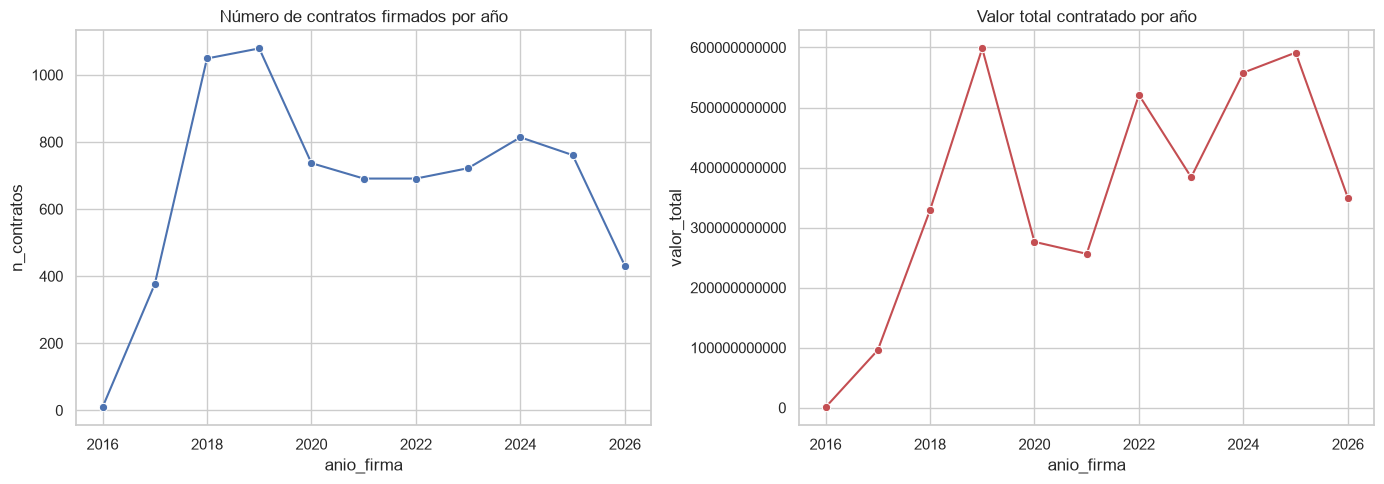

,anio_firma,n_contratos,valor_total
0,2016,9,6.880196e+08
1,2017,376,9.583462e+10
2,2018,1049,3.288999e+11
3,2019,1079,5.984102e+11
4,2020,737,2.762815e+11
5,2021,691,2.562981e+11
6,2022,691,5.209862e+11
7,2023,722,3.839399e+11
8,2024,814,5.580542e+11
9,2025,761,5.914494e+11


In [4]:
serie_anual = df.dropna(subset=['anio_firma']).groupby('anio_firma').agg(
    n_contratos=('valor_del_contrato', 'size'),
    valor_total=('valor_contrato_capped', 'sum')
).reset_index()
serie_anual['anio_firma'] = serie_anual['anio_firma'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=serie_anual, x='anio_firma', y='n_contratos', marker='o', ax=axes[0])
axes[0].set_title('Número de contratos firmados por año')

sns.lineplot(data=serie_anual, x='anio_firma', y='valor_total', marker='o', ax=axes[1], color='#C44E52')
axes[1].set_title('Valor total contratado por año')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()
serie_anual

serie mensual


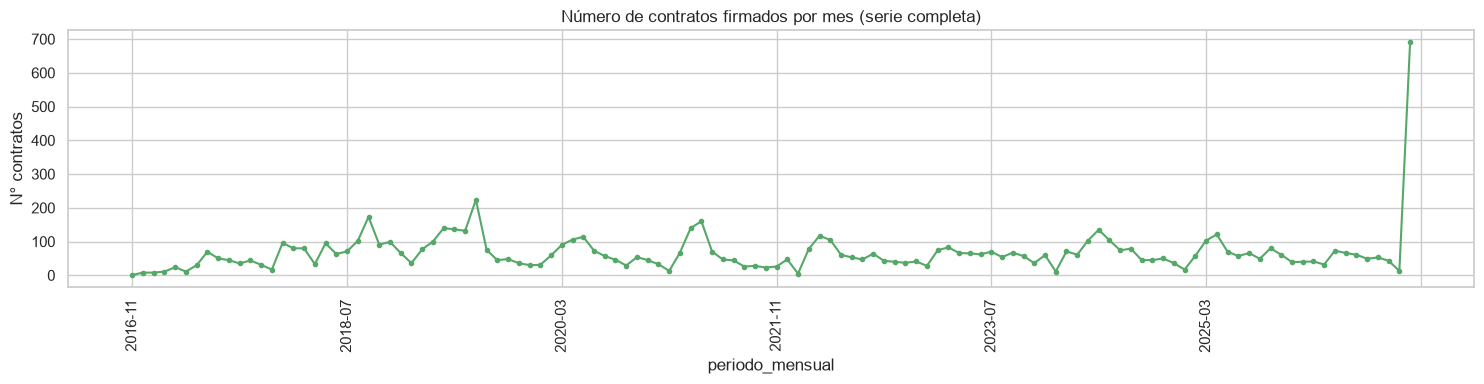

In [5]:
serie_mensual = df.dropna(subset=['periodo_mensual']).groupby('periodo_mensual').size()

plt.figure(figsize=(15, 4))
serie_mensual.plot(kind='line', marker='.', color='#55A868')
plt.title('Número de contratos firmados por mes (serie completa)')
plt.ylabel('N° contratos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Patron estacional agregado

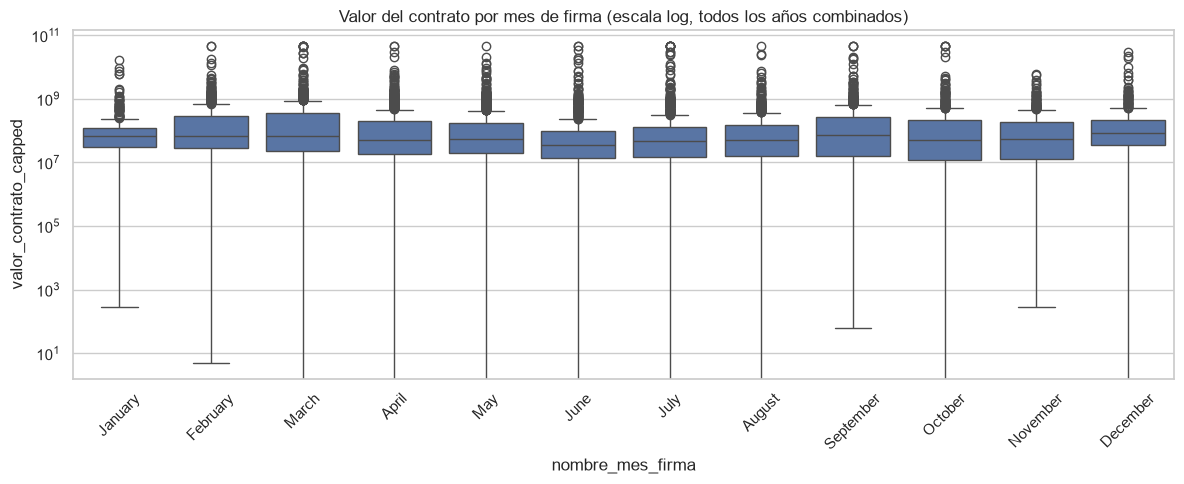

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='nombre_mes_firma', y='valor_contrato_capped', data=df, order=orden_meses)
plt.yscale('log')
plt.title('Valor del contrato por mes de firma (escala log, todos los años combinados)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

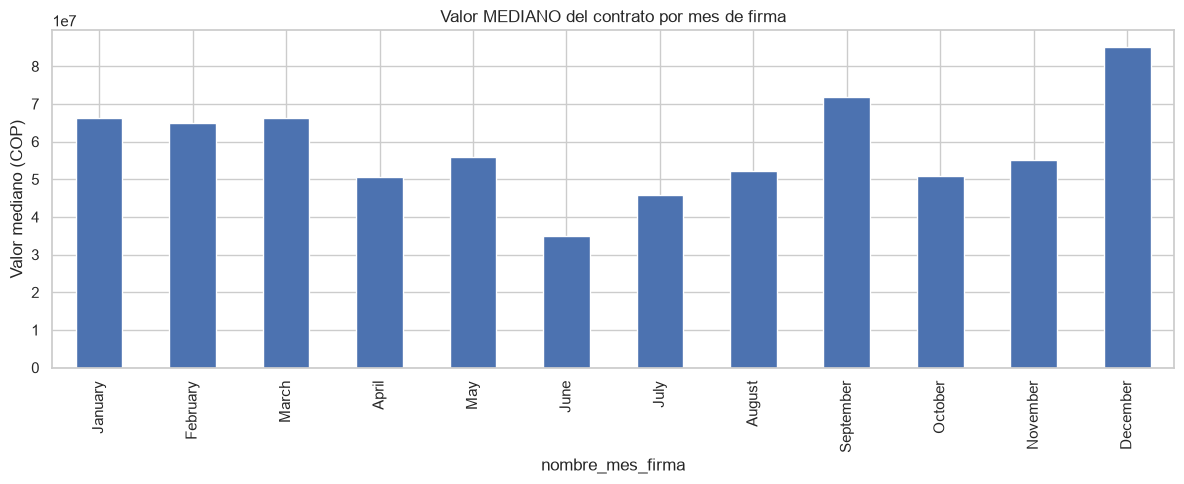

In [9]:
mediana_por_mes = df.groupby('nombre_mes_firma')['valor_del_contrato'].median().reindex(orden_meses)

plt.figure(figsize=(12, 5))
mediana_por_mes.plot(kind='bar', color='#4C72B0')
plt.title('Valor MEDIANO del contrato por mes de firma')
plt.ylabel('Valor mediano (COP)')
plt.tight_layout()
plt.show()

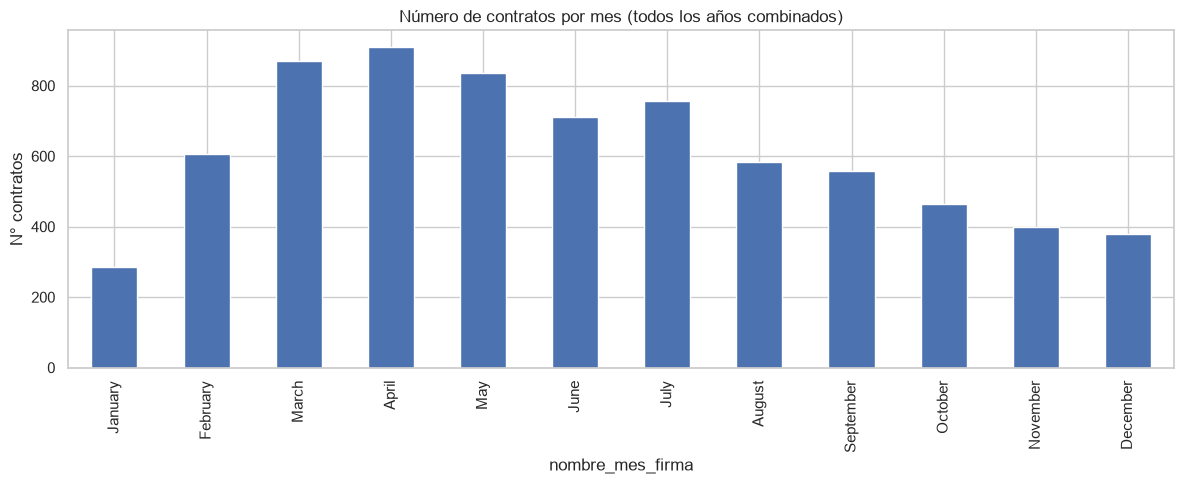

In [7]:
conteo_por_mes = df.groupby('nombre_mes_firma').size().reindex(orden_meses)

plt.figure(figsize=(12, 5))
conteo_por_mes.plot(kind='bar', color='#4C72B0')
plt.title('Número de contratos por mes (todos los años combinados)')
plt.ylabel('N° contratos')
plt.tight_layout()
plt.show()

### Prueba 1 — Kruskal-Wallis: ¿el valor del contrato difiere entre trimestres?

Evaluamos si la distribución del monto de los contratos cambia dependiendo de la época del año.

* **$H_0$:** El valor del contrato tiene la misma distribución en los 4 trimestres.
* **$H_1$:** Al menos un trimestre difiere.

In [10]:
grupos_trimestre = [
    df.loc[df['trimestre_firma'] == t, 'valor_contrato_capped'].dropna()
    for t in sorted(df['trimestre_firma'].dropna().unique())
]

h_stat, p_valor = stats.kruskal(*grupos_trimestre)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p-valor = {p_valor:.4f}")
print("Conclusión:", "Se rechaza H0: el valor difiere significativamente entre trimestres (p < 0.05)" if p_valor < 0.05 else "No se rechaza H0: no hay evidencia de diferencia por trimestre")

print()
for t, g in zip(sorted(df['trimestre_firma'].dropna().unique()), grupos_trimestre):
    print(f"  Trimestre {int(t)}: mediana = ${g.median():,.0f}  (n={len(g)})")

Kruskal-Wallis H = 59.41, p-valor = 0.0000
Conclusión: Se rechaza H0: el valor difiere significativamente entre trimestres (p < 0.05)

  Trimestre 1: mediana = $66,000,000  (n=1764)
  Trimestre 2: mediana = $50,000,000  (n=2458)
  Trimestre 3: mediana = $53,000,000  (n=1897)
  Trimestre 4: mediana = $62,472,900  (n=1241)


### Prueba 2 — Chi-cuadrado de bondad de ajuste: ¿los contratos se distribuyen uniforme entre los 12 meses?

Analizamos si el número de contratos se reparte equitativamente a lo largo del año o si hay meses con picos y caídas de actividad.

* **$H_0$:** El número de contratos es igual en los 12 meses (no hay estacionalidad).
* **$H_1$:** Hay meses con más/menos actividad de la esperada por azar.

In [11]:
conteo_observado = df.groupby('mes_firma').size().reindex(range(1,13), fill_value=0)
esperado_uniforme = [conteo_observado.sum()/12] * 12

chi2, p_valor = stats.chisquare(conteo_observado, f_exp=esperado_uniforme)
print(f"Chi-cuadrado = {chi2:.2f}, p-valor = {p_valor:.2e}")
print("Conclusión:", "Se rechaza H0: la contratación NO es uniforme en el año, hay estacionalidad (p < 0.05)" if p_valor < 0.05 else "No se rechaza H0")

print()
print(conteo_observado)

Chi-cuadrado = 765.30, p-valor = 5.32e-157
Conclusión: Se rechaza H0: la contratación NO es uniforme en el año, hay estacionalidad (p < 0.05)

mes_firma
1     286
2     607
3     871
4     911
5     837
6     710
7     756
8     583
9     558
10    463
11    400
12    378
dtype: int64


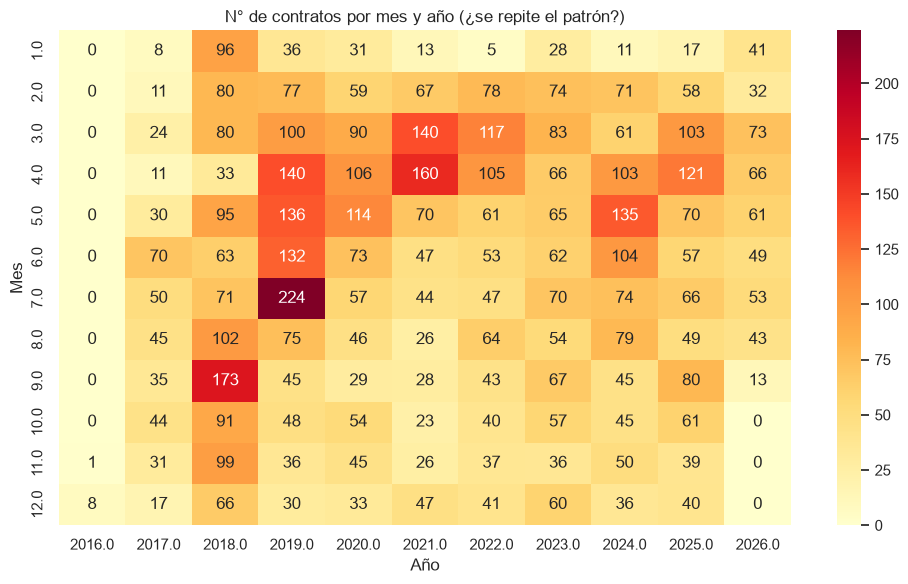

In [ ]:
tabla_mes_anio = df.pivot_table(
    index='mes_firma', columns='anio_firma',
    values='valor_del_contrato', aggfunc='count', fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_mes_anio, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('N° de contratos por mes y año')
plt.ylabel('Mes')
plt.xlabel('Año')
plt.tight_layout()
plt.show()